# 20_04 — Evaluación predictiva · Escenario 1

Paso **3b** del ciclo. Supone que `20_03_convergencia` dio veredicto ✓; si las
cadenas no convergieron, nada de lo que sigue significa algo.


## Qué se reporta

| Sección | Qué responde |
|---|---|
| 4 | métricas puntuales y distribucionales, **train vs test** |
| 5 | bandas de credibilidad sobre la serie de cada score |
| 6 | intervalos sobre la curva, en extractos cada 10 períodos |
| 7 | ventana móvil: cómo evoluciona el error al cruzar $T_0$ |
| 8 | calibración: PIT por bloque |

Todo el cálculo vive en `fit/` y todo el dibujo en `graphics/`: este notebook
sólo orquesta.

## 1. Imports, rutas y artefactos

In [21]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

from model_psbp_fd.pipelines import (
    cargar_curvas, cargar_curvas_true, cargar_fpca, cargar_estandarizador,
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.models.pspb_fd_v3 import PSBPPredictor, PropagadorFuncional

from model_psbp_fd.fit import (
    # puntual
    rmse_por_coeficiente, r2_por_columna, razon_dispersion, mise, rmse_funcional,
    # distribucional muestral
    crps_muestral, energy_score, cobertura, intervalo_muestral,
    pit_muestral, diagnostico_pit,
    # agrupación de cadenas y ventana móvil
    agrupar_momentos, ventana_movil_scores, ventana_movil_funcional,
)
from model_psbp_fd.graphics import (
    plot_ventana_movil, plot_bandas_serie, plot_extractos_curvas,
    plot_calibracion_pit, plot_scatter_theta,
)
from model_psbp_fd.utils import get_project_root

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [22]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] debe coincidir con 20_01, 20_03 y psbp_fd_iteracion.m
BASENAME, ESCENARIO_ID, REPLICA_ID = "escenario", 1, 1
M_FPCA = 1   # [BARRIDO] debe ser el mismo que en 20_01; viaja en el ID
EXPERIMENT_ID = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}_m{M_FPCA:02d}"

PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / EXPERIMENT_ID,
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / EXPERIMENT_ID,
    "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / EXPERIMENT_ID,
    "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / EXPERIMENT_ID,
}
for r in PATHS.values():
    r.mkdir(parents=True, exist_ok=True)
print(f"EXPERIMENT_ID : {EXPERIMENT_ID}")

EXPERIMENT_ID : escenario_1_r01_m01


In [23]:
dfs_train, manifest = cargar_datasets_ar(PATHS, bloque="train")
dfs_test,  _        = cargar_datasets_ar(PATHS, bloque="test")
hp_json     = cargar_hiperparametros(PATHS)
eval_config = cargar_config_evaluacion(PATHS)

COMPONENT_IDX = manifest["component_idx"]
n_components  = len(COMPONENT_IDX)
cov_names     = manifest["cov_names"]
N_LAGS        = int(manifest["n_lags"])
T, T0         = int(manifest["T"]), int(manifest["T0"])
N_ITER        = int(hp_json["n_iter"])
MCMC_CFG      = hp_json["mcmc_config"]
BURN          = int(MCMC_CFG["burn"])

assert manifest["scores_scale"] == "standardized_zscore_ddof0"

# Parámetros de evaluación: se LEEN del artefacto, no se redeclaran aquí.
NIVEL        = float(eval_config.get("nivel_credibilidad", 0.95))
MODO_RESIDUO = eval_config.get("modo_residuo", "ninguno")
OBJETIVO     = eval_config.get("objetivo_evaluacion", "curva_verdadera")
VENTANAS_W   = list(eval_config.get("ventana_movil", {}).get("w", [10, 20, 40]))

print(f"T={T}  T0={T0}  n_lags={N_LAGS}  componentes={n_components}")
print(f"nivel={NIVEL}  ·  modo_residuo={MODO_RESIDUO!r}  ·  objetivo={OBJETIVO!r}")
print(f"ventanas w = {VENTANAS_W}")

T=400  T0=280  n_lags=1  componentes=1
nivel=0.95  ·  modo_residuo='ninguno'  ·  objetivo='curva_verdadera'
ventanas w = [10, 20, 40]


In [24]:
fpca = cargar_fpca(PATHS)
_ver = fpca.verificar()
assert _ver["todo_ok"], f"Las identidades FPCA no se cumplen: {_ver}"

scores_standardizer = cargar_estandarizador(PATHS, DataStandardizer)
X_obs, grilla = cargar_curvas(PATHS)                 # (T, G) con ruido
X_true        = cargar_curvas_true(PATHS)            # (T, G) verdadera — el objetivo

M_fpca   = fpca.M
Psi_grid, mu_grid = fpca.Psi_grid, fpca.mu_grid
SCORES     = fpca.SCORES                              # (T, M) escala original
SCORES_STD = scores_standardizer.transform(SCORES)

print(f"FPCA M={M_fpca} K={fpca.K}   ·   curvas {X_true.shape}  grilla {grilla.shape}")
print(f"sd(observada − verdadera) = {(X_obs - X_true).std():.4f}   "
      "← el ruido que el modelo NO debe predecir")
assert COMPONENT_IDX == list(range(M_fpca)), (
    "La propagación funcional necesita el vector completo de scores en orden; "
    f"COMPONENT_IDX={COMPONENT_IDX} y M={M_fpca}.")

FPCA M=1 K=4   ·   curvas (400, 75)  grilla (75,)
sd(observada − verdadera) = 0.2503   ← el ruido que el modelo NO debe predecir


## 2. Trazas MCMC

In [25]:
def ruta_traza(fpc_idx, chain):
    return PATHS["out_artefact"] / f"chain_fpc_{fpc_idx}_iter{chain:02d}.mat"


def leer_traza(path):
    m = loadmat(str(path))
    claves = ["betajhout", "beta0hout", "tauhout", "alphahout", "psijhout",
              "Gammajhout", "gammajhout", "pijout", "wjout", "osumout", "inEout"]
    traces = {k: np.asarray(m[k], dtype=np.float64) for k in claves}
    burn = int(np.asarray(m["burn"]).ravel()[0])
    feat = str(np.atleast_1d(m["feature_names"]).ravel()[0]).split(",")
    return traces, burn, feat


class ModeloTraza:
    def __init__(self, traces, burn, feature_names):
        self.traces = traces
        self.feature_names_ = list(feature_names)
        self.burn = int(burn)
        self.predictor_ = PSBPPredictor(traces=traces, burn=burn)

    def _diseno(self, df):
        Xp = np.asarray(df.iloc[:, 1:], dtype=float)
        return np.hstack([np.ones((Xp.shape[0], 1)), Xp])

    def momentos(self, df):
        return self.predictor_.momentos_predictivos(self._diseno(df))

    def muestrear(self, df, d=1, seed=None):
        return self.predictor_.muestrear(self._diseno(df), d, seed=seed)


faltan = [ruta_traza(COMPONENT_IDX[k] + 1, c + 1).name
          for k in range(n_components) for c in range(N_ITER)
          if not ruta_traza(COMPONENT_IDX[k] + 1, c + 1).exists()]
assert not faltan, f"Faltan trazas: {faltan}. Ejecuta psbp_fd_iteracion.m."

models_chains = {k: {} for k in range(n_components)}
for k in range(n_components):
    esperado = list(dfs_train[k].columns[1:])
    for c in range(N_ITER):
        traces, burn, feat = leer_traza(ruta_traza(COMPONENT_IDX[k] + 1, c + 1))
        assert feat == esperado, f"[k={k} c={c+1}] feature_names ≠ columnas del dataset."
        models_chains[k][c] = ModeloTraza(traces, burn, feat)

n_post = MCMC_CFG["nsim"] - BURN
print(f"✓ {n_components} × {N_ITER} cadenas · {n_post} draws posteriores c/u")

✓ 1 × 3 cadenas · 1500 draws posteriores c/u


## 3. Predicción a $h=1$ sobre la serie completa

Los dos bloques se concatenan en **una sola serie de orígenes**
$t=N_{lags}+1,\dots,T$. Ésa es la diferencia con el flujo anterior, que sólo
evaluaba el bloque de prueba: sin el tramo de entrenamiento no hay con qué
comparar el salto en $T_0$, que es la lectura principal de la ventana móvil.

En todos los orígenes la predicción usa los **rezagos reales** —nunca
predicciones encadenadas—, de modo que el horizonte es 1 en todo el recorrido y
el modelo no se reentrena en ningún punto.

In [26]:
# Número de extracciones de la predictiva por draw posterior. El total es
#     S = (nsim - burn) × S_POR_ITER × n_cadenas
# y d=1 ya da varios miles: subirlo sólo reduce el error Monte Carlo de estimar
# los cuantiles, no cambia la predictiva.

S_POR_ITER = 10
SEED_PRED  = 20260823

# Serie completa de orígenes: train (t = N_LAGS+1 … T0) seguido de test.
dfs_full = {k: pd.concat([dfs_train[k], dfs_test[k]], ignore_index=True)
            for k in range(n_components)}
n_orig   = len(dfs_full[0])
t_orig   = np.arange(N_LAGS + 1, T + 1)          # tiempo del experimento, base-1
assert len(t_orig) == n_orig, f"{len(t_orig)} ≠ {n_orig}"

# Índice del corte dentro de la serie de orígenes (los primeros N_LAGS no existen)
T0_orig  = T0 - N_LAGS
es_train = t_orig <= T0
print(f"orígenes evaluados: {n_orig}  (train {es_train.sum()} · test {(~es_train).sum()})")

_mem_gb = n_post * S_POR_ITER * N_ITER * n_orig * n_components * 4 / 1e9
print(f"SC_draws reservará {_mem_gb * 1e3:.0f} MB en float32")
assert _mem_gb < 2.0, (
    f"SC_draws pediría {_mem_gb:.1f} GB. Baja S_POR_ITER antes de continuar.")

orígenes evaluados: 399  (train 279 · test 120)
SC_draws reservará 72 MB en float32


In [27]:
# Momentos y extracciones por score, agrupando cadenas.
#   momentos : ley de varianza total entre cadenas (fit.agrupar_momentos)
#   muestras : concatenación, que es la mezcla de igual peso
Y_obs  = np.column_stack([dfs_full[k].iloc[:, 0].to_numpy() for k in range(n_components)])
Y_hat  = np.empty_like(Y_obs)
Y_sd   = np.empty_like(Y_obs)

S_POR_CADENA = n_post * S_POR_ITER
S_total      = S_POR_CADENA * N_ITER
SC_draws     = np.empty((S_total, n_orig, n_components), dtype=np.float32)

for k in range(n_components):
    medias, sds = [], []
    for j, c in enumerate(sorted(models_chains[k])):
        mom = models_chains[k][c].momentos(dfs_full[k])
        medias.append(mom["media"])
        sds.append(mom["sd"])            # PREDICTIVA (v3), no la del centro
        muestras_c = models_chains[k][c].muestrear(
            dfs_full[k], S_POR_ITER, seed=SEED_PRED + 1000 * k + c)
        assert muestras_c.shape == (S_POR_CADENA, n_orig), (
            f"[k={k} c={c}] muestrear devolvió {muestras_c.shape}; se esperaba "
            f"({S_POR_CADENA}, {n_orig}). ¿nsim/burn del .mat difieren del JSON?")
        SC_draws[j * S_POR_CADENA:(j + 1) * S_POR_CADENA, :, k] = muestras_c
        del muestras_c
    Y_hat[:, k], Y_sd[:, k] = agrupar_momentos(np.column_stack(medias),
                                               np.column_stack(sds))

li_s, ls_s = intervalo_muestral(SC_draws, nivel=NIVEL)   # (n_orig, M)

print(f"extracciones por score: S = {S_total} "
      f"= {n_post} draws × {S_POR_ITER} × {N_ITER} cadenas")
print(f"SC_draws {SC_draws.shape} {SC_draws.dtype} "
      f"({SC_draws.nbytes / 1e6:.0f} MB)  ·  bandas {li_s.shape}")

extracciones por score: S = 45000 = 1500 draws × 10 × 3 cadenas
SC_draws (45000, 399, 1) float32 (72 MB)  ·  bandas (399, 1)


### 3.1 Propagación a la curva

$\hat X^{(s)}_t(\tau)=\mu(\tau)+\sum_m (d_m\tilde\xi^{(s)}_{tm}+c_m)\psi_m(\tau)$,
que es (3.41) del documento. Con `modo_residuo="ninguno"` el mapa es
determinista y las curvas son extracciones exactas de la predictiva de la curva
**proyectada**.

Las muestras funcionales se **adelgazan** antes de propagar: el arreglo completo
sería $(S, n, G)$ y con $S$ de varios miles ocupa más de un gigabyte sin que los
cuantiles al 95 % mejoren de forma apreciable.

In [28]:
# Adelgazamiento para la propagación funcional. Con S_FUNC ≈ 500 el error
# Monte Carlo de un cuantil al 2.5% es del orden de 0.01 en escala de cuantil,
# despreciable frente al ancho de la banda.
S_FUNC = 500
paso_thin = max(1, S_total // S_FUNC)
SC_thin = SC_draws[::paso_thin]

propagador = PropagadorFuncional(Psi_grid, mu_grid,
                                 estandarizador=scores_standardizer,
                                 modo_residuo=MODO_RESIDUO)
X_draws = propagador.curvas_desde_scores(SC_thin, seed=SEED_PRED)   # (S', n, G)
X_pred  = X_draws.mean(axis=0)                                       # (n, G)
li_f, ls_f = np.quantile(X_draws, (1 - NIVEL) / 2, axis=0), \
             np.quantile(X_draws, 1 - (1 - NIVEL) / 2, axis=0)

# Curvas de referencia alineadas a los orígenes evaluados
X_true_ev = X_true[N_LAGS:]     # (n_orig, G) VERDADERA — contra esto se evalúa
X_obs_ev  = X_obs[N_LAGS:]      # (n_orig, G) observada, sólo para las figuras

print(f"muestras funcionales {X_draws.shape}  (adelgazado 1 de cada {paso_thin})")
print(f"memoria ≈ {X_draws.nbytes / 1e6:.0f} MB")

# Piso de error: la mejor curva alcanzable con M componentes, sin modelo alguno.
X_proj = fpca.reconstruct(SCORES)[N_LAGS:]
print(f"\nMISE del TRUNCAMIENTO (proyección FPCA de la curva verdadera): "
      f"{mise(X_true_ev, X_proj, grilla):.6f}")
print("   ← ningún modelo sobre esta representación puede bajar de ahí")

muestras funcionales (500, 399, 75)  (adelgazado 1 de cada 90)
memoria ≈ 120 MB

MISE del TRUNCAMIENTO (proyección FPCA de la curva verdadera): 0.248049
   ← ningún modelo sobre esta representación puede bajar de ahí


## 4. Métricas, entrenamiento contra prueba

La comparación train/test es la que separa el ajuste de la generalización.
En el Escenario 1 —control, FAR(1) estacionario— **las dos columnas deberían
parecerse**: si el test se degrada mucho hay sobreajuste, y ese resultado es la
referencia contra la cual leer los escenarios 2–6.

In [29]:
def _metricas_bloque(mask, etiqueta):
    """Métricas puntuales y distribucionales sobre un subconjunto de orígenes."""
    filas = []
    for k in range(n_components):
        y, p = Y_obs[mask, k], Y_hat[mask, k]
        z    = SC_draws[:, mask, k]
        cob  = cobertura(y, li_s[mask, k], ls_s[mask, k])
        pit  = pit_muestral(y, z)
        filas.append({
            "bloque":  etiqueta,
            "FPC":     f"FPC {COMPONENT_IDX[k] + 1}",
            "RMSE":    float(rmse_por_coeficiente(y[:, None], p[:, None])[0]),
            "R2":      float(r2_por_columna(y[:, None], p[:, None], centrar=True)[0]),
            "sd_ratio": float(razon_dispersion(y[:, None], p[:, None])[0]),
            "CRPS":    float(crps_muestral(y, z).mean()),
            f"Cob{int(NIVEL*100)}": cob["cobertura"],
            "Ancho":   cob["ancho_medio"],
            "PIT_ks":  float(diagnostico_pit(pit)["ks"]),
            "PIT_forma": diagnostico_pit(pit)["forma"],
            "n":       int(mask.sum()),
        })
    return filas

met_df = pd.DataFrame(_metricas_bloque(es_train, "train")
                      + _metricas_bloque(~es_train, "test"))
met_df = met_df.set_index(["bloque", "FPC"])
met_df.to_csv(PATHS["out_report"] / "50_metricas_scores.csv")

_num = [c for c in met_df.columns if met_df[c].dtype.kind == "f"]
display(met_df.style
    .format({c: "{:.4f}" for c in _num})
    .background_gradient(subset=["RMSE", "CRPS"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2"], cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=[f"Cob{int(NIVEL*100)}"], cmap="RdYlGn",
                         vmin=0.80, vmax=1.0)
    .set_caption("Métricas por score y bloque · CRPS y cobertura desde la "
                 "predictiva MUESTRAL"))

_deg = (met_df.loc["test", "RMSE"].mean() / met_df.loc["train", "RMSE"].mean())
print(f"\nRMSE test / RMSE train = {_deg:.3f}"
      + ("   ✓ sin degradación apreciable" if _deg < 1.15
         else "   ← el modelo se degrada fuera de muestra"))

,,RMSE,R2,sd_ratio,CRPS,Cob95,Ancho,PIT_ks,PIT_forma,n
bloque,FPC,,,,,,,,,
train,FPC 1,0.8307,0.3090,0.5426,0.4725,0.9570,3.2896,0.0443,aproximadamente uniforme,279
test,FPC 1,0.8281,0.4677,0.5284,0.4692,0.9333,3.3532,0.0515,aproximadamente uniforme,120



RMSE test / RMSE train = 0.997   ✓ sin degradación apreciable


In [30]:
# Métricas funcionales, contra la curva VERDADERA
filas_f = []
for mask, etq in ((es_train, "train"), (~es_train, "test")):
    dentro = (X_true_ev[mask] >= li_f[mask]) & (X_true_ev[mask] <= ls_f[mask])
    filas_f.append({
        "bloque": etq,
        "MISE":   mise(X_true_ev[mask], X_pred[mask], grilla),
        "RMSE_f": rmse_funcional(X_true_ev[mask], X_pred[mask], grilla),
        "MISE_truncamiento": mise(X_true_ev[mask], X_proj[mask], grilla),
        "energy": energy_score(X_true_ev[mask], X_draws[:, mask, :],
                               max_pares=2000, seed=0),
        f"Cob{int(NIVEL*100)}_puntual": float(dentro.mean()),
        "ancho_medio": float((ls_f[mask] - li_f[mask]).mean()),
        "n": int(mask.sum()),
    })
fun_df = pd.DataFrame(filas_f).set_index("bloque")
fun_df.to_csv(PATHS["out_report"] / "51_metricas_funcionales.csv")

display(fun_df.style.format("{:.6f}", subset=["MISE", "RMSE_f", "MISE_truncamiento"])
        .format("{:.4f}", subset=["energy", f"Cob{int(NIVEL*100)}_puntual", "ancho_medio"])
        .set_caption("Métricas funcionales contra la curva VERDADERA · "
                     "banda sin residuo de representación"))

_frac = fun_df["MISE_truncamiento"] / fun_df["MISE"]
print("\nfracción del MISE atribuible al truncamiento FPCA:")
for b in fun_df.index:
    print(f"  {b:5s}: {_frac[b]:.1%}"
          + ("   ← el techo de la representación domina; subir M rinde más "
             "que mejorar el modelo" if _frac[b] > 0.7 else ""))
print(f"\nLa cobertura es PUNTUAL (cada tau por separado), NO simultánea sobre "
      f"la curva.")

,MISE,RMSE_f,MISE_truncamiento,energy,Cob95_puntual,ancho_medio,n
bloque,,,,,,,
train,1.063520,1.031271,0.243109,5.7504,0.8996,3.5192,279
test,1.079999,1.039230,0.259535,5.7553,0.9003,3.5868,120



fracción del MISE atribuible al truncamiento FPCA:
  train: 22.9%
  test : 24.0%

La cobertura es PUNTUAL (cada tau por separado), NO simultánea sobre la curva.


## 5. Bandas de credibilidad sobre la serie de scores

[plot_bandas_serie] inicio (1 pasos)
  1/1 (100.0%) t=0.0s eta=0.0s  FPC 1: cob train=0.957 (+0.007) test=0.933 (-0.017) | ancho train=3.29 test=3.353 | 20/399 fuera
[plot_bandas_serie] listo: 1 pasos en 0.3s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_1_r01_m01\52_bandas_scores.png


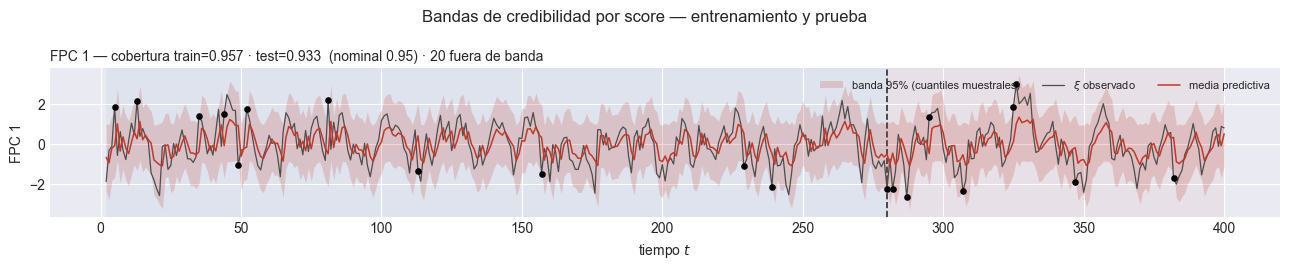

In [31]:
plot_bandas_serie(
    Y_obs, Y_hat, li_s, ls_s, T0, t=t_orig,
    etiquetas=[f"FPC {i + 1}" for i in COMPONENT_IDX], nivel=NIVEL,
    title="Bandas de credibilidad por score — entrenamiento y prueba",
    save_path=str(PATHS["out_report"] / "52_bandas_scores.png"),
    verbose=True)
plt.show()

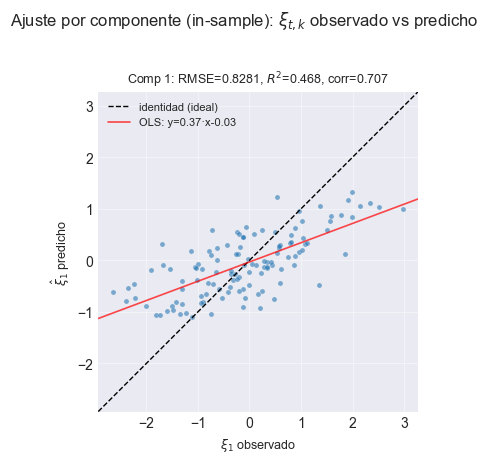

In [32]:
eval_scatter = {k: {"y_obs": Y_obs[~es_train, k], "y_hat": Y_hat[~es_train, k]}
                for k in range(n_components)}
plot_scatter_theta(eval_scatter, n_components=n_components,
                   save_path=str(PATHS["out_report"] / "53_scatter_scores_test.png"))
plt.show()

## 6. Intervalos de credibilidad sobre la curva

Extractos de la serie funcional cada `CADA` períodos, cada uno con su banda
puntual, la curva verdadera y —en gris— los datos observados, para ver de un
vistazo dónde estaba el ruido que la banda **no** tiene que cubrir.

[plot_extractos_curvas] inicio (20 pasos)
  1/20 ( 5.0%) t=0.0s eta=0.1s  t=2 [train] cob=1.000 rmse=1.349
  2/20 (10.0%) t=0.0s eta=0.1s  t=22 [train] cob=0.813 rmse=1.502
  3/20 (15.0%) t=0.0s eta=0.1s  t=42 [train] cob=0.560 rmse=1.738
  4/20 (20.0%) t=0.0s eta=0.1s  t=62 [train] cob=0.987 rmse=0.6446
  5/20 (25.0%) t=0.0s eta=0.1s  t=82 [train] cob=1.000 rmse=1.503
  6/20 (30.0%) t=0.1s eta=0.1s  t=102 [train] cob=1.000 rmse=0.6753
  7/20 (35.0%) t=0.1s eta=0.1s  t=122 [train] cob=1.000 rmse=0.8532
  8/20 (40.0%) t=0.1s eta=0.1s  t=142 [train] cob=0.933 rmse=0.8423
  9/20 (45.0%) t=0.1s eta=0.1s  t=162 [train] cob=1.000 rmse=0.3322
  10/20 (50.0%) t=0.1s eta=0.1s  t=182 [train] cob=1.000 rmse=0.2971
  11/20 (55.0%) t=0.1s eta=0.1s  t=202 [train] cob=1.000 rmse=0.563
  12/20 (60.0%) t=0.1s eta=0.1s  t=222 [train] cob=1.000 rmse=0.8592
  13/20 (65.0%) t=0.1s eta=0.1s  t=242 [train] cob=0.787 rmse=1.223
  14/20 (70.0%) t=0.1s eta=0.1s  t=262 [train] cob=1.000 rmse=0.7139
  15/20 (75.0

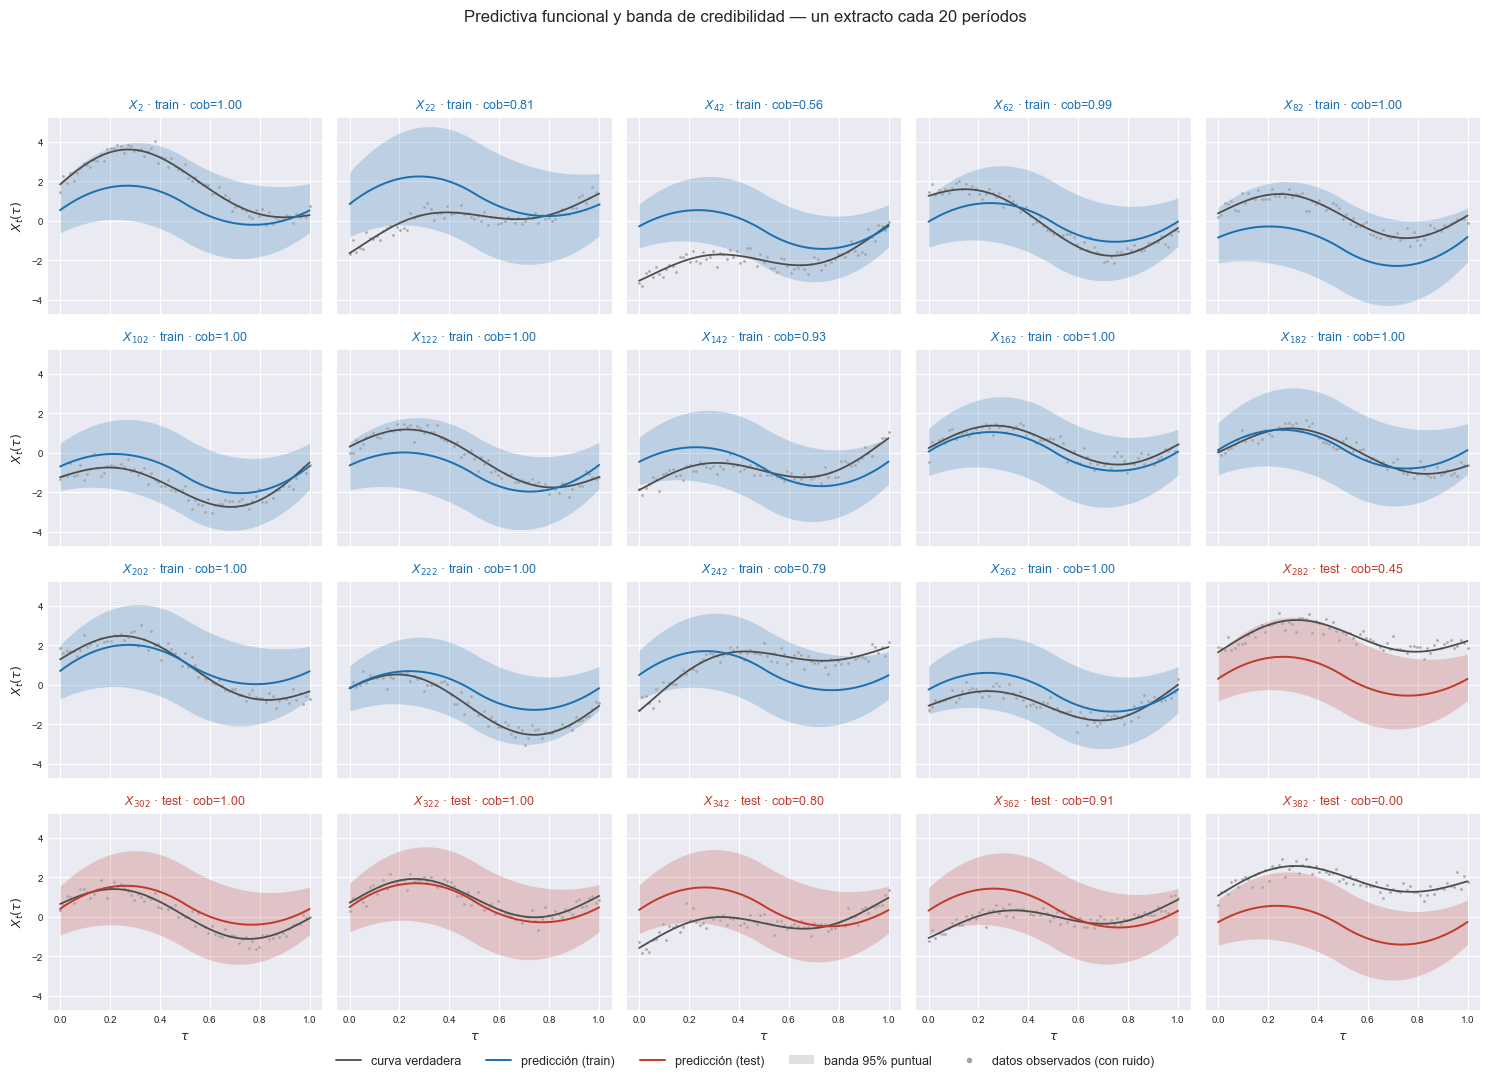

In [33]:
CADA = 20   # [CONFIG] un extracto cada CADA períodos

plot_extractos_curvas(
    X_true_ev, X_pred, li_f, ls_f, grilla, T0, t=t_orig,
    cada=CADA, n_col=5, nivel=NIVEL, X_obs=X_obs_ev,
    title="Predictiva funcional y banda de credibilidad",
    save_path=str(PATHS["out_report"] / "54_extractos_curvas.png"),
    verbose=True)
plt.show()

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=277 [train] cob=1.000 rmse=0.2216
  2/7 (28.6%) t=0.0s eta=0.0s  t=278 [train] cob=1.000 rmse=0.808
  3/7 (42.9%) t=0.0s eta=0.0s  t=279 [train] cob=1.000 rmse=0.2868
  4/7 (57.1%) t=0.0s eta=0.0s  t=280 [train] cob=0.347 rmse=1.981
  5/7 (71.4%) t=0.0s eta=0.0s  t=281 [test] cob=1.000 rmse=0.4686
  6/7 (85.7%) t=0.0s eta=0.0s  t=282 [test] cob=0.453 rmse=2.01
  7/7 (100.0%) t=0.1s eta=0.0s  t=283 [test] cob=1.000 rmse=0.3723
[plot_extractos_curvas] listo: 7 pasos en 1.1s  cob media train=0.837 test=0.818 (nominal 0.95)


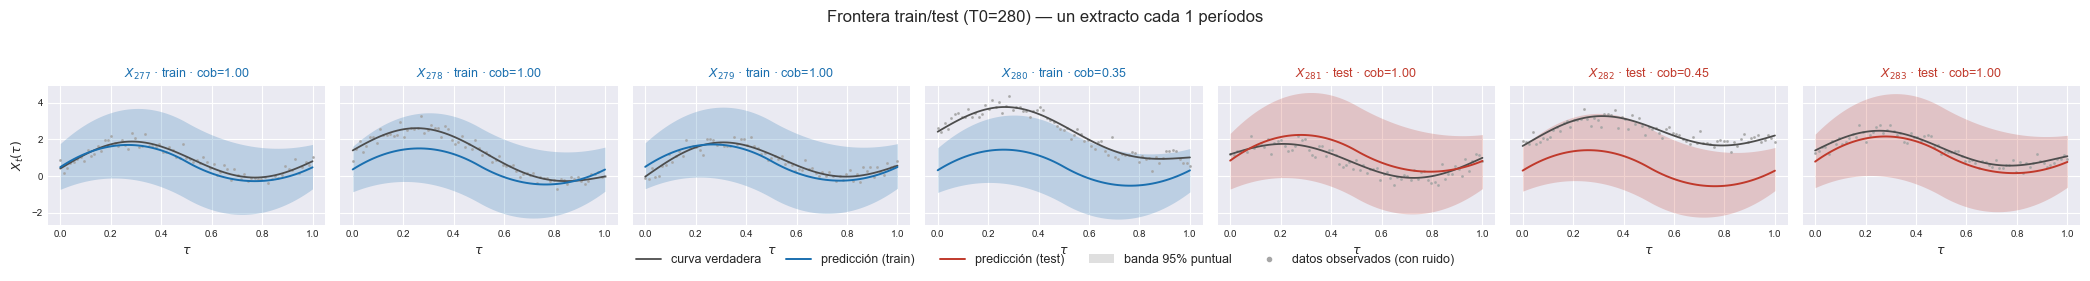

In [34]:
# Zoom sobre la frontera: los últimos orígenes de train y los primeros de test.
# Es donde se ve, curva a curva, si la banda se ensancha al salir de muestra.
i_corte = int(np.searchsorted(t_orig, T0))
sel = np.arange(max(0, i_corte - 3), min(n_orig, i_corte + 4))

plot_extractos_curvas(
    X_true_ev[sel], X_pred[sel], li_f[sel], ls_f[sel], grilla, T0,
    t=t_orig[sel], cada=1, n_col=len(sel), nivel=NIVEL, X_obs=X_obs_ev[sel],
    title=f"Frontera train/test (T0={T0})",
    save_path=str(PATHS["out_report"] / "55_extractos_frontera.png"),
    verbose=True)
plt.show()

## 7. Ventana móvil

El modelo **no se reentrena**: lo que se desliza es la ventana de evaluación.
Cada punto agrega las métricas de $w$ orígenes consecutivos, todos a $h=1$ con
los rezagos reales. Se superponen varios anchos para que la conclusión no
dependa de un $w$ elegido a dedo; las ventanas que **cruzan** $T_0$ van
punteadas, porque su cifra mezcla dentro y fuera de muestra.

[ventana_movil_scores[FPC 1, w=20]] inicio (380 pasos)
  1/380 ( 0.3%) t=0.0s eta=10.8s  t=11 [train] rmse=1.066
  19/380 ( 5.0%) t=0.5s eta=9.2s  t=29 [train] rmse=0.8024
  38/380 (10.0%) t=1.0s eta=8.7s  t=48 [train] rmse=1.011
  57/380 (15.0%) t=1.5s eta=8.2s  t=67 [train] rmse=0.7593
  76/380 (20.0%) t=2.0s eta=7.9s  t=86 [train] rmse=0.9723
  95/380 (25.0%) t=2.5s eta=7.4s  t=105 [train] rmse=0.7431
  114/380 (30.0%) t=3.0s eta=6.9s  t=124 [train] rmse=0.7252
  133/380 (35.0%) t=3.4s eta=6.4s  t=143 [train] rmse=0.6205
  152/380 (40.0%) t=3.9s eta=5.9s  t=162 [train] rmse=0.7791
  171/380 (45.0%) t=4.4s eta=5.4s  t=181 [train] rmse=0.8073
  190/380 (50.0%) t=4.9s eta=4.9s  t=200 [train] rmse=0.7674
  209/380 (55.0%) t=5.4s eta=4.4s  t=219 [train] rmse=0.7512
  228/380 (60.0%) t=5.9s eta=3.9s  t=238 [train] rmse=0.9283
  247/380 (65.0%) t=6.4s eta=3.4s  t=257 [train] rmse=0.7262
  266/380 (70.0%) t=6.8s eta=2.9s  t=276 [train] rmse=0.9358
  285/380 (75.0%) t=7.3s eta=2.4s  t=295 [t

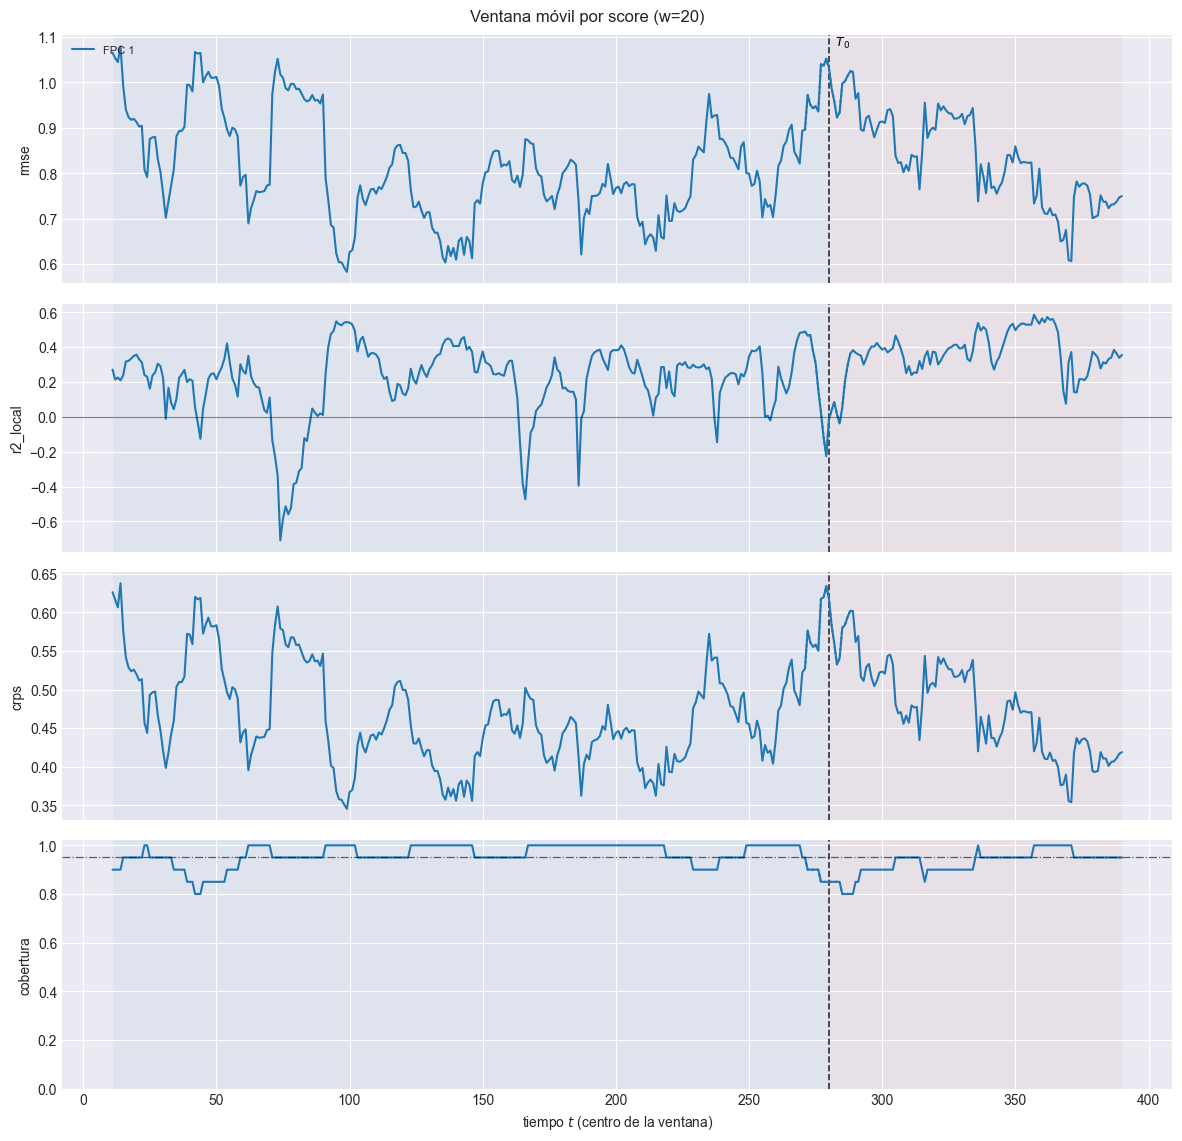

In [35]:
# `w_ref` se define antes del diccionario para pedir el progreso solo del
# ancho de referencia: con verbose en todos los anchos la salida serian
# cientos de lineas. Su valor es el mismo de antes.
w_ref = VENTANAS_W[len(VENTANAS_W) // 2]
tablas_score = {
    w: ventana_movil_scores(
        Y_obs, Y_hat, T0_orig, w=w, muestras=SC_draws, li=li_s, ls=ls_s,
        t_offset=N_LAGS,
        etiquetas=[f"FPC {i + 1}" for i in COMPONENT_IDX],
        verbose=(w == w_ref))
    for w in VENTANAS_W
}
tablas_score[w_ref].to_csv(PATHS["out_report"] / f"56_ventana_scores_w{w_ref}.csv",
                           index=False)

plot_ventana_movil(
    tablas_score[w_ref], T0, ["rmse", "r2_local", "crps", "cobertura"],
    columna_grupo="componente",
    title=f"Ventana móvil por score (w={w_ref})",
    save_path=str(PATHS["out_report"] / "56_ventana_scores.png"),
    verbose=True)
plt.show()

[ventana_movil_funcional[w=20]] inicio (380 pasos)
  1/380 ( 0.3%) t=0.0s eta=0.4s  t=11 [train] mise=1.691
  19/380 ( 5.0%) t=0.0s eta=0.1s  t=29 [train] mise=1.075
  38/380 (10.0%) t=0.0s eta=0.1s  t=48 [train] mise=1.434
  57/380 (15.0%) t=0.0s eta=0.0s  t=67 [train] mise=0.8256
  76/380 (20.0%) t=0.0s eta=0.0s  t=86 [train] mise=1.347
  95/380 (25.0%) t=0.0s eta=0.0s  t=105 [train] mise=0.8364
  114/380 (30.0%) t=0.0s eta=0.0s  t=124 [train] mise=0.8747
  133/380 (35.0%) t=0.0s eta=0.0s  t=143 [train] mise=0.6824
  152/380 (40.0%) t=0.0s eta=0.0s  t=162 [train] mise=1.033
  171/380 (45.0%) t=0.0s eta=0.0s  t=181 [train] mise=1.034
  190/380 (50.0%) t=0.0s eta=0.0s  t=200 [train] mise=0.8783
  209/380 (55.0%) t=0.0s eta=0.0s  t=219 [train] mise=0.9303
  228/380 (60.0%) t=0.0s eta=0.0s  t=238 [train] mise=1.3
  247/380 (65.0%) t=0.0s eta=0.0s  t=257 [train] mise=0.7776
  266/380 (70.0%) t=0.0s eta=0.0s  t=276 [train] mise=1.375
  285/380 (75.0%) t=0.0s eta=0.0s  t=295 [test] mise=1.2

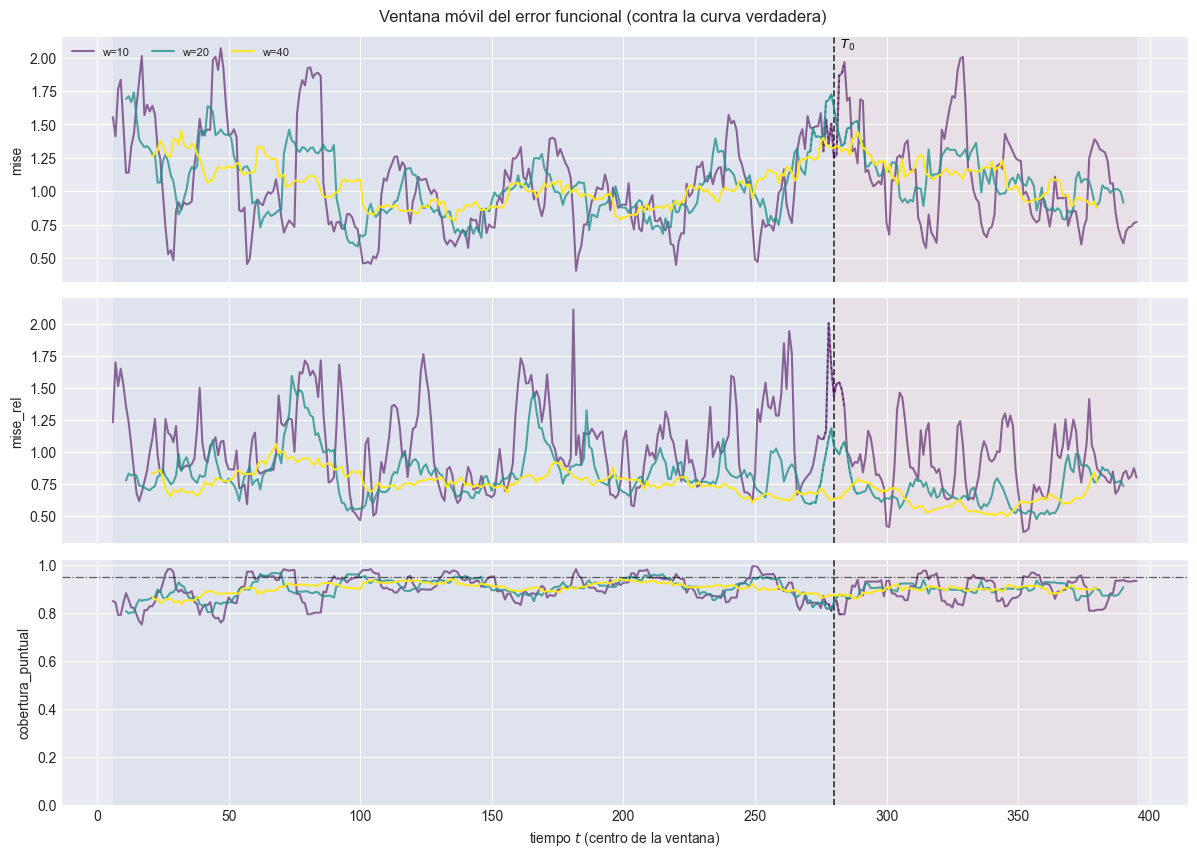

In [36]:
tablas_fun = {
    w: ventana_movil_funcional(X_true_ev, X_pred, grilla, T0_orig, w=w,
                               li=li_f, ls=ls_f, t_offset=N_LAGS,
                               verbose=(w == w_ref))
    for w in VENTANAS_W
}
tablas_fun[w_ref].to_csv(PATHS["out_report"] / f"57_ventana_funcional_w{w_ref}.csv",
                         index=False)

plot_ventana_movil(
    tablas_fun[w_ref], T0, ["mise", "mise_rel", "cobertura_puntual"],
    tablas_por_w=tablas_fun,
    title="Ventana móvil del error funcional (contra la curva verdadera)",
    save_path=str(PATHS["out_report"] / "57_ventana_funcional.png"),
    verbose=True)
plt.show()

In [37]:
# Lectura numérica del salto en T0, excluyendo las ventanas que lo cruzan.
print(f"{'w':>4}  {'MISE train':>11}  {'MISE test':>11}  {'salto':>7}")
print(f"{'─'*4}  {'─'*11}  {'─'*11}  {'─'*7}")
for w in VENTANAS_W:
    t_ = tablas_fun[w]
    limpio = t_[~t_["cruza_T0"]]
    a = limpio.loc[limpio.bloque == "train", "mise"].mean()
    b = limpio.loc[limpio.bloque == "test",  "mise"].mean()
    print(f"{w:>4}  {a:>11.6f}  {b:>11.6f}  {b/a:>6.2f}×")


   w   MISE train    MISE test    salto
────  ───────────  ───────────  ───────
  10     1.046402     1.075112    1.03×
  20     1.030277     1.074791    1.04×
  40     1.018655     1.075128    1.06×


## 8. Calibración

Bajo calibración perfecta el PIT es uniforme. La **forma** dice qué falla: una
U indica bandas demasiado angostas, una campana demasiado anchas, y una
pendiente un sesgo del centro. Contrastar train contra test separa el desajuste
del modelo de la pérdida de calibración fuera de muestra.

[plot_calibracion_pit] inicio (1 pasos)
  1/1 (100.0%) t=0.0s eta=0.0s  FPC 1  train: media=0.501 desv_max=0.470 n=279  |  test: media=0.499 desv_max=0.417 n=120
[plot_calibracion_pit] listo: 1 pasos en 0.1s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_1_r01_m01\58_pit.png


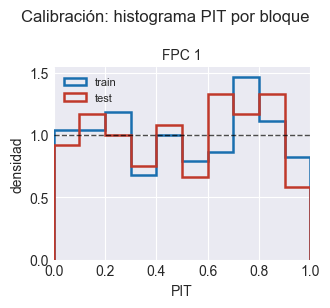

  FPC 1:  train KS=0.044 (aproximadamente uniforme)   test KS=0.051 (aproximadamente uniforme)


In [38]:
pit_tr = {f"FPC {COMPONENT_IDX[k]+1}": pit_muestral(Y_obs[es_train, k],
                                                    SC_draws[:, es_train, k])
          for k in range(n_components)}
pit_te = {f"FPC {COMPONENT_IDX[k]+1}": pit_muestral(Y_obs[~es_train, k],
                                                    SC_draws[:, ~es_train, k])
          for k in range(n_components)}

plot_calibracion_pit(pit_tr, pit_te,
                     save_path=str(PATHS["out_report"] / "58_pit.png"),
                     verbose=True)
plt.show()

for nombre in pit_tr:
    d_tr, d_te = diagnostico_pit(pit_tr[nombre]), diagnostico_pit(pit_te[nombre])
    print(f"  {nombre}:  train KS={d_tr['ks']:.3f} ({d_tr['forma']})   "
          f"test KS={d_te['ks']:.3f} ({d_te['forma']})")

## 9. Comparación con las líneas base

In [39]:
_bl = PATHS["out_report"] / "30_baselines_test.csv"
rmse_psbp = met_df.loc["test", "RMSE"].mean()
print(f"RMSE promedio en scores — PSBP-FD (test): {rmse_psbp:.4f}\n")

if _bl.exists():
    baselines_df = pd.read_csv(_bl, index_col=0)
    display(baselines_df.style.format("{:.4f}", na_rep="—")
            .set_caption("Líneas base sobre el bloque de prueba (h=1)"))
    if "RMSE_scores_prom" in baselines_df.columns:
        for modelo, fila in baselines_df.iterrows():
            marca = "✓ PSBP mejor" if rmse_psbp < fila["RMSE_scores_prom"] else "✗ baseline mejor"
            print(f"  vs {modelo:24s} RMSE={fila['RMSE_scores_prom']:.4f}  → {marca}")
else:
    print("⚠ falta 30_baselines_test.csv — ejecuta 20_01 §6.")


RMSE promedio en scores — PSBP-FD (test): 0.8281



,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,120.0000,1.1393,1.1393,-0.0075,1.8268,1.3516
persistencia_lag1,120.0000,0.8788,0.8788,0.4006,1.1861,1.0891


  vs media_incondicional      RMSE=1.1393  → ✓ PSBP mejor
  vs persistencia_lag1        RMSE=0.8788  → ✓ PSBP mejor


In [40]:
# ── Resumen ejecutable del experimento ───────────────────────────────────────
resumen = {
    "experiment_id": EXPERIMENT_ID,
    "objetivo_evaluacion": OBJETIVO,
    "modo_residuo": MODO_RESIDUO,
    "nivel": NIVEL,
    "S_scores": int(S_total), "S_funcional": int(X_draws.shape[0]),
    "rmse_scores_train": float(met_df.loc["train", "RMSE"].mean()),
    "rmse_scores_test":  float(met_df.loc["test", "RMSE"].mean()),
    "mise_train": float(fun_df.loc["train", "MISE"]),
    "mise_test":  float(fun_df.loc["test", "MISE"]),
    "mise_truncamiento_test": float(fun_df.loc["test", "MISE_truncamiento"]),
    f"cobertura_puntual_test": float(fun_df.loc["test", f"Cob{int(NIVEL*100)}_puntual"]),
}
pd.Series(resumen).to_csv(PATHS["out_report"] / "59_resumen.csv", header=False)
for k, v in resumen.items():
    print(f"  {k:26s}: {v}")
print(f"\nFiguras y tablas en {PATHS['out_report']}")

  experiment_id             : escenario_1_r01_m01
  objetivo_evaluacion       : curva_verdadera
  modo_residuo              : ninguno
  nivel                     : 0.95
  S_scores                  : 45000
  S_funcional               : 500
  rmse_scores_train         : 0.8306934902749413
  rmse_scores_test          : 0.8281006190315148
  mise_train                : 1.063519935140473
  mise_test                 : 1.0799990739091834
  mise_truncamiento_test    : 0.259534727433717
  cobertura_puntual_test    : 0.9003333333333333

Figuras y tablas en C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_1_r01_m01
